### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.applications import ResNet50, Xception, EfficientNetV2S, VGG16
from tensorflow.keras.layers import Dense, Flatten
from sklearn.metrics import classification_report
import warnings
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, matthews_corrcoef, cohen_kappa_score
)
import seaborn as sns
warnings.filterwarnings("ignore")

2024-07-16 15:07:15.178031: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


## Load dataset
dataset contains pf header info

This dataset contains headers of 1986 binary executable 

In [2]:
df = pd.read_csv('pe_headers.csv')

In [3]:
# preview data
df.head()

,GR,0,1,2,3,4,5,6,7,8,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
0,0,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
1,0,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
2,0,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
3,0,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
4,0,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# PE Header 1024
df.iloc[:, 1:]

,0,1,2,3,4,5,6,7,8,9,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
0,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
1,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
2,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
3,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
4,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1980,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
1981,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
1982,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
1983,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
df.sample(9,random_state=42)

,GR,0,1,2,3,4,5,6,7,8,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
582,0,77,90,80,0,2,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
1711,1,77,90,80,0,2,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
1052,1,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
1075,1,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
917,0,77,90,80,0,2,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
70,0,77,90,80,0,2,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
429,0,77,90,144,0,3,0,0,0,4,...,5,0,0,50,17,0,38,17,0,221
903,0,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
914,0,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0


### Plot sample images

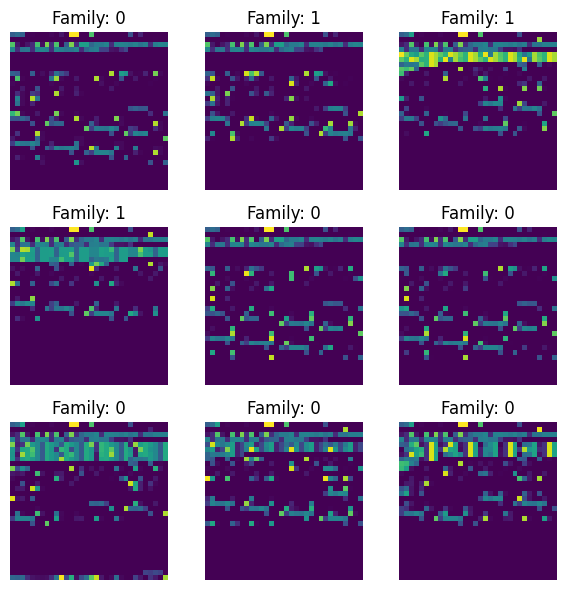

In [6]:
samp  = df.sample(9,random_state=42)
# Convert the numerical columns to color images
samp_images = samp.iloc[:, 1:].values.reshape(-1, 32, 32,1)
# Normalize the image values to [0, 1]
samp_images = samp_images / 255.0

# Create a new figure and plot the images
fig, axes = plt.subplots(3, 3, figsize=(6, 6))

# Flatten the axes array to make it easier to iterate over
axes = axes.flatten()

# Iterate over each image and plot it
for i in range(len(axes)):
    ax = axes[i]
    ax.imshow(samp_images[i], cmap='viridis')  # Assuming grayscale images
    ax.axis('off')  # Turn off axis labels
    ax.set_title(f'Family: {samp.iloc[i, 0]}')

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

## Convert to colored and Split data

In [7]:
#val_df['GR'].value_counts()

In [8]:
# Split the data into training and validation sets (80% for training, 20% for validation)
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

# Convert the numerical columns to image
train_images = train_df.iloc[:, 1:].values.reshape(-1, 32, 32,1)
val_images = val_df.iloc[:, 1:].values.reshape(-1, 32, 32,1)

# Normalize the image values to [0, 1]
train_images = train_images / 255.0
val_images = val_images / 255.0

# Convert the numerical columns to color images
train_images = np.repeat(train_images, 3, axis=3)
val_images = np.repeat(val_images, 3, axis=3)

reshape data for deep learning architecture compatibility

In [9]:
# Reshape each image in train_images to (256, 256, 3)
train_images = tf.image.resize(train_images, (256, 256))

# Reshape each image in val_images to (256, 256, 3)
val_images = tf.image.resize(val_images, (256, 256))

#train_images = tf.image.grayscale_to_rgb(train_images)
#val_images = tf.image.grayscale_to_rgb(val_images)

2024-07-16 15:07:29.219324: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [10]:
train_images[1].shape

TensorShape([256, 256, 3])

## Build Resnet model for Goodware and randsomeware detection

In [11]:
# get target label
train_labels = train_df['GR'].values
val_labels = val_df['GR'].values

In [12]:
train_labels

array([0, 0, 0, ..., 0, 1, 1])

In [13]:
# Define the ResNet model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

# Flatten the output from the base model
x = Flatten()(base_model.output)

# Add a dense layer with 26 units for classification
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
x = Dense(1, activation='sigmoid')(x) #Dense(2, activation='softmax')(x)

# Define the model
model = tf.keras.Model(inputs=base_model.input, outputs=x)

# Freeze some layers
for layer in base_model.layers:
    layer.trainable = False


In [14]:
#model.summary()

In [16]:
# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [17]:
# train model
model.fit(train_images, train_labels, epochs=20, validation_data=(val_images, val_labels))

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - accuracy: 0.5238 - loss: 2.7217 - val_accuracy: 0.5113 - val_loss: 0.6681
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.5847 - loss: 0.6822 - val_accuracy: 0.6499 - val_loss: 0.6173
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.6116 - loss: 0.6453 - val_accuracy: 0.7406 - val_loss: 0.5547
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.6506 - loss: 0.6340 - val_accuracy: 0.7380 - val_loss: 0.5323
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.6578 - loss: 0.6192 - val_accuracy: 0.7683 - val_loss: 0.5173
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.7028 - loss: 0.5346 - val_accuracy: 0.5743 - val_loss: 0.6664
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.6387 - loss: 0.6464 - val_accuracy: 0.7456 - val_loss: 0.5448
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.7531 - loss: 0.4864 - val_accuracy: 0.7330 - v

In [18]:
# Evaluate the model on the validation set
y_pred = model.predict(val_images)

13/13 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step


In [19]:
# Convert the predictions to labels (0 or 1)
y_pred_labels = (y_pred > 0.5).astype(int)

# Get the true labels
y_true = val_labels

# Print the classification report
print(classification_report(y_true, y_pred_labels,target_names=['Goodware','Ransomeware']))

              precision    recall  f1-score   support

    Goodware       0.94      0.46      0.61       191
 Ransomeware       0.66      0.97      0.78       206

    accuracy                           0.72       397
   macro avg       0.80      0.71      0.70       397
weighted avg       0.79      0.72      0.70       397



In [20]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred_labels)
tn, fp, fn, tp = cm.ravel()

# Precision
precision = precision_score(y_true, y_pred_labels)

# Recall
recall = recall_score(y_true, y_pred_labels)

# Accuracy
accuracy = accuracy_score(y_true, y_pred_labels)

# FN rate (False Negative Rate)
fn_rate = fn / (fn + tp)

# FP rate (False Positive Rate)
fp_rate = fp / (fp + tn)

# F-measure
f_measure = f1_score(y_true, y_pred_labels)

# Error rate
error_rate = 1 - accuracy

# Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_true, y_pred_labels)

# Kappa
kappa = cohen_kappa_score(y_true, y_pred_labels)

# AUC-ROC
auc_roc = roc_auc_score(y_true, y_pred)

# Print the classification report
print(classification_report(y_true, y_pred_labels, target_names=['Goodware', 'Ransomeware']))

# Print all the metrics
print(f"Confusion Matrix: \n{cm}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"FN Rate: {fn_rate:.4f}")
print(f"FP Rate: {fp_rate:.4f}")
print(f"F-measure: {f_measure:.4f}")
print(f"Error Rate: {error_rate:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Kappa: {kappa:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")

              precision    recall  f1-score   support

    Goodware       0.94      0.46      0.61       191
 Ransomeware       0.66      0.97      0.78       206

    accuracy                           0.72       397
   macro avg       0.80      0.71      0.70       397
weighted avg       0.79      0.72      0.70       397

Confusion Matrix: 
[[ 87 104]
 [  6 200]]
Precision: 0.6579
Recall: 0.9709
Accuracy: 0.7229
FN Rate: 0.0291
FP Rate: 0.5445
F-measure: 0.7843
Error Rate: 0.2771
MCC: 0.5030
Kappa: 0.4345
AUC-ROC: 0.8996


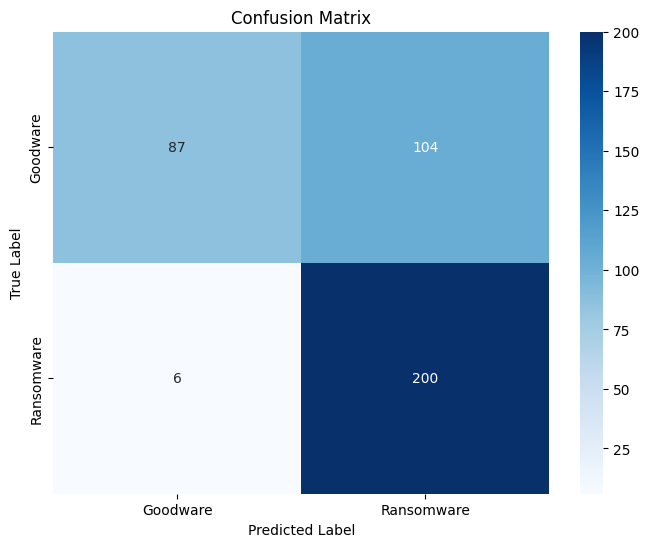

In [21]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Goodware', 'Ransomware'], yticklabels=['Goodware', 'Ransomware'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [22]:
lines = classification_report(y_true, y_pred_labels).split('\n')
recall_scores = [float(line.split()[2]) for line in lines[2:4]]

In [23]:
recall_scores

[0.46, 0.97]

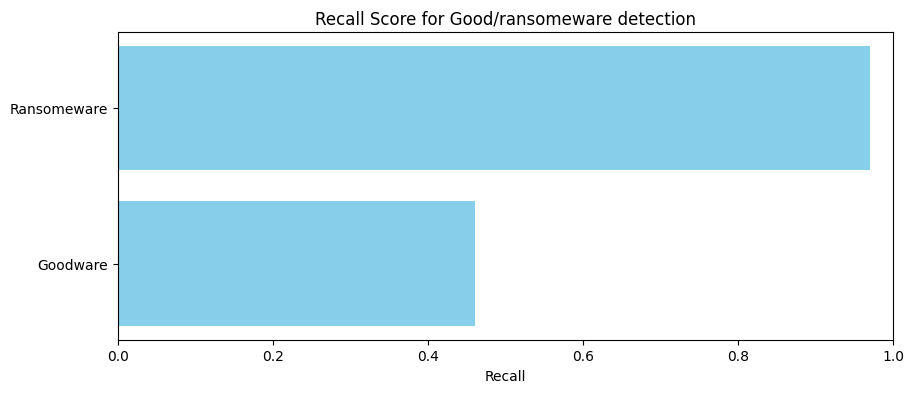

In [24]:
plt.figure(figsize=(10, 4))
plt.barh(['Goodware','Ransomeware'], recall_scores, color='skyblue')
plt.xlabel('Recall')
plt.title('Recall Score for Good/ransomeware detection')
plt.xlim(0, 1)  # Set x-axis limit to ensure consistency
plt.show()

## Build Xception model for Goodware/Ransomeware detection

In [11]:
# get target label
train_labels = train_df['GR'].values
val_labels = val_df['GR'].values


In [12]:
# Define the ResNet model
base_model = Xception(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

# Flatten the output from the base model
x = Flatten()(base_model.output)

# Add a dense layer with 26 units for classification
x = Dense(256, activation='relu')(x)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
x = Dense(1, activation='sigmoid')(x) #Dense(2, activation='softmax')(x)

# Define the model
model_xception = tf.keras.Model(inputs=base_model.input, outputs=x)

# Freeze some layers
for layer in base_model.layers:
    layer.trainable = False


In [13]:
# Compile the model
model_xception.compile(optimizer='Adamax', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
# train model
model_xception.fit(train_images, train_labels, epochs=15, validation_data=(val_images, val_labels))

Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 143s 3s/step - accuracy: 0.6235 - loss: 1.4695 - val_accuracy: 0.7406 - val_loss: 0.4998
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 137s 3s/step - accuracy: 0.8226 - loss: 0.3705 - val_accuracy: 0.8438 - val_loss: 0.3677
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 137s 3s/step - accuracy: 0.8686 - loss: 0.3111 - val_accuracy: 0.8388 - val_loss: 0.3353
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 138s 3s/step - accuracy: 0.9204 - loss: 0.2072 - val_accuracy: 0.8564 - val_loss: 0.3205
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 137s 3s/step - accuracy: 0.9316 - loss: 0.1901 - val_accuracy: 0.8917 - val_loss: 0.3016
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 137s 3s/step - accuracy: 0.9373 - loss: 0.1644 - val_accuracy: 0.8967 - val_loss: 0.2823
Epoch 7/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 137s 3s/step - accuracy: 0.9559 - loss: 0.1213 - val_accuracy: 0.8615 - val_loss: 0.3582
Epoch 8/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 137s 3s/step - accuracy: 0.9554 - loss: 0.1422 - val_accuracy: 0.8917 - v

In [ ]:
# Evaluate the model on the validation set
y_pred = model_xception.predict(val_images)

13/13 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step


In [ ]:
# Convert the predictions to labels (0 or 1)
y_pred_labels = (y_pred > 0.5).astype(int)

# Get the true labels
y_true = val_labels

# Print the classification report
print(classification_report(y_true, y_pred_labels,target_names=['Goodware','Ransomeware']))

              precision    recall  f1-score   support

    Goodware       0.86      0.91      0.88       191
 Ransomeware       0.91      0.86      0.89       206

    accuracy                           0.88       397
   macro avg       0.88      0.88      0.88       397
weighted avg       0.89      0.88      0.88       397



In [ ]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred_labels)
tn, fp, fn, tp = cm.ravel()

# Precision
precision = precision_score(y_true, y_pred_labels)

# Recall
recall = recall_score(y_true, y_pred_labels)

# Accuracy
accuracy = accuracy_score(y_true, y_pred_labels)

# FN rate (False Negative Rate)
fn_rate = fn / (fn + tp)

# FP rate (False Positive Rate)
fp_rate = fp / (fp + tn)

# F-measure
f_measure = f1_score(y_true, y_pred_labels)

# Error rate
error_rate = 1 - accuracy

# Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_true, y_pred_labels)

# Kappa
kappa = cohen_kappa_score(y_true, y_pred_labels)

# AUC-ROC
auc_roc = roc_auc_score(y_true, y_pred)

# Print the classification report
print(classification_report(y_true, y_pred_labels, target_names=['Goodware', 'Ransomeware']))

# Print all the metrics
print(f"Confusion Matrix: \n{cm}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"FN Rate: {fn_rate:.4f}")
print(f"FP Rate: {fp_rate:.4f}")
print(f"F-measure: {f_measure:.4f}")
print(f"Error Rate: {error_rate:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Kappa: {kappa:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")

              precision    recall  f1-score   support

    Goodware       0.86      0.91      0.88       191
 Ransomeware       0.91      0.86      0.89       206

    accuracy                           0.88       397
   macro avg       0.88      0.88      0.88       397
weighted avg       0.89      0.88      0.88       397

Confusion Matrix: 
[[173  18]
 [ 28 178]]
Precision: 0.9082
Recall: 0.8641
Accuracy: 0.8841
FN Rate: 0.1359
FP Rate: 0.0942
F-measure: 0.8856
Error Rate: 0.1159
MCC: 0.7693
Kappa: 0.7684
AUC-ROC: 0.9531


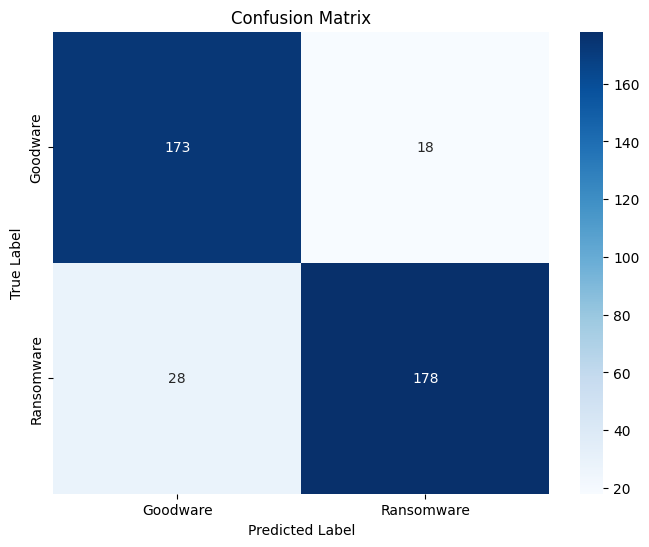

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Goodware', 'Ransomware'], yticklabels=['Goodware', 'Ransomware'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

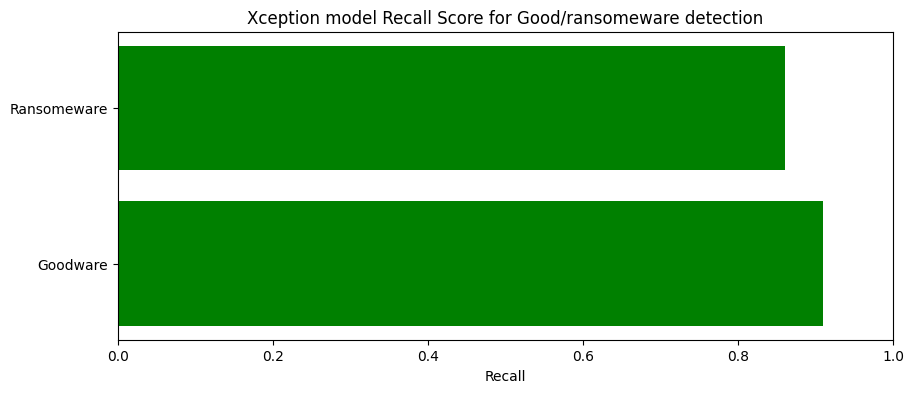

In [ ]:
lines = classification_report(y_true, y_pred_labels).split('\n')
recall_scores = [float(line.split()[2]) for line in lines[2:4]]

plt.figure(figsize=(10, 4))
plt.barh(['Goodware','Ransomeware'], recall_scores, color='green')
plt.xlabel('Recall')
plt.title('Xception model Recall Score for Good/ransomeware detection')
plt.xlim(0, 1)  # Set x-axis limit to ensure consistency
plt.show()

## Build VGG16 model for Goodware/Ransomeware detection

In [ ]:
# get target label
train_labels = train_df['GR'].values
val_labels = val_df['GR'].values


In [ ]:
# Define the ResNet model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

# Flatten the output from the base model
x = Flatten()(base_model.output)

# Add a dense layer with 26 units for classification
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
x = Dense(1, activation='sigmoid')(x) #Dense(2, activation='softmax')(x)

# Define the model
model_VGG = tf.keras.Model(inputs=base_model.input, outputs=x)

# Freeze some layers
for layer in base_model.layers:
    layer.trainable = False


In [ ]:
# Compile the model
model_VGG.compile(optimizer='RMSprop', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
# train model
model_VGG.fit(train_images, train_labels, epochs=5, validation_data=(val_images, val_labels))

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 301s 6s/step - accuracy: 0.5278 - loss: 2.1534 - val_accuracy: 0.5239 - val_loss: 0.6873
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 299s 6s/step - accuracy: 0.6106 - loss: 0.6140 - val_accuracy: 0.5264 - val_loss: 0.7087
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 300s 6s/step - accuracy: 0.6867 - loss: 0.5713 - val_accuracy: 0.8136 - val_loss: 0.4367
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 299s 6s/step - accuracy: 0.7450 - loss: 0.5010 - val_accuracy: 0.7884 - val_loss: 0.4817
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 299s 6s/step - accuracy: 0.7911 - loss: 0.4408 - val_accuracy: 0.8262 - val_loss: 0.4065


In [ ]:
# Evaluate the model on the validation set
y_pred = model_VGG.predict(val_images)

 3/13 ━━━━━━━━━━━━━━━━━━━━ 48s 5s/step

In [ ]:
# Convert the predictions to labels (0 or 1)
y_pred_labels = (y_pred > 0.5).astype(int)

# Get the true labels
y_true = val_labels

# Print the classification report
print(classification_report(y_true, y_pred_labels,target_names=['Goodware','Ransomeware']))

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred_labels)
tn, fp, fn, tp = cm.ravel()

# Precision
precision = precision_score(y_true, y_pred_labels)

# Recall
recall = recall_score(y_true, y_pred_labels)

# Accuracy
accuracy = accuracy_score(y_true, y_pred_labels)

# FN rate (False Negative Rate)
fn_rate = fn / (fn + tp)

# FP rate (False Positive Rate)
fp_rate = fp / (fp + tn)

# F-measure
f_measure = f1_score(y_true, y_pred_labels)

# Error rate
error_rate = 1 - accuracy

# Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_true, y_pred_labels)

# Kappa
kappa = cohen_kappa_score(y_true, y_pred_labels)

# AUC-ROC
auc_roc = roc_auc_score(y_true, y_pred)

# Print the classification report
print(classification_report(y_true, y_pred_labels, target_names=['Goodware', 'Ransomeware']))

# Print all the metrics
print(f"Confusion Matrix: \n{cm}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"FN Rate: {fn_rate:.4f}")
print(f"FP Rate: {fp_rate:.4f}")
print(f"F-measure: {f_measure:.4f}")
print(f"Error Rate: {error_rate:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Kappa: {kappa:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Goodware', 'Ransomware'], yticklabels=['Goodware', 'Ransomware'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
lines = classification_report(y_true, y_pred_labels).split('\n')
recall_scores = [float(line.split()[2]) for line in lines[2:4]]

plt.figure(figsize=(10, 4))
plt.barh(['Goodware','Ransomeware'], recall_scores, color='red')
plt.xlabel('Recall')
plt.title('VGG16 model Recall Score for Good/ransomeware detection')
plt.xlim(0, 1)  # Set x-axis limit to ensure consistency
plt.show()